In [2]:
import os
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import zipfile 
from pathlib import Path

import missingno as msno


In [3]:
zip_path = Path("C:\\Users\\chris\\Initiez_vous_au_ML_Ops\\Projet+Mise+en+prod+-+home-credit-default-risk.zip")
extract_dir = Path("data")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Extraction terminée !")

Extraction terminée !


In [47]:
bureau_balance = pd.read_csv(r"C:\Users\chris\Initiez_vous_au_ML_Ops\data\bureau_balance.csv")
print('Bureau balance data shape: ', bureau_balance.shape)
bureau_balance.head()

Bureau balance data shape:  (27299925, 3)


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [48]:
# colonne MONTHS_BALANCE de bureau_balance: c'est le mois de l’observation du crédit par rapport à la date de demande de crédit
# -1 = le mois précédent la demande de crédit, -2 = 2 mois avant la demande de crédit, 

# colonne STATUS de bureau_balance: représente l’état mensuel du crédit à savoir: comportement de paiement du client 
# - 0 : le client a payé à temps
# Les retards (1–5) sont des signaux de risque: 1 = retard de 1 mois, 5= retard de 5 mois !!!
# C= close et X= without information

<Axes: >

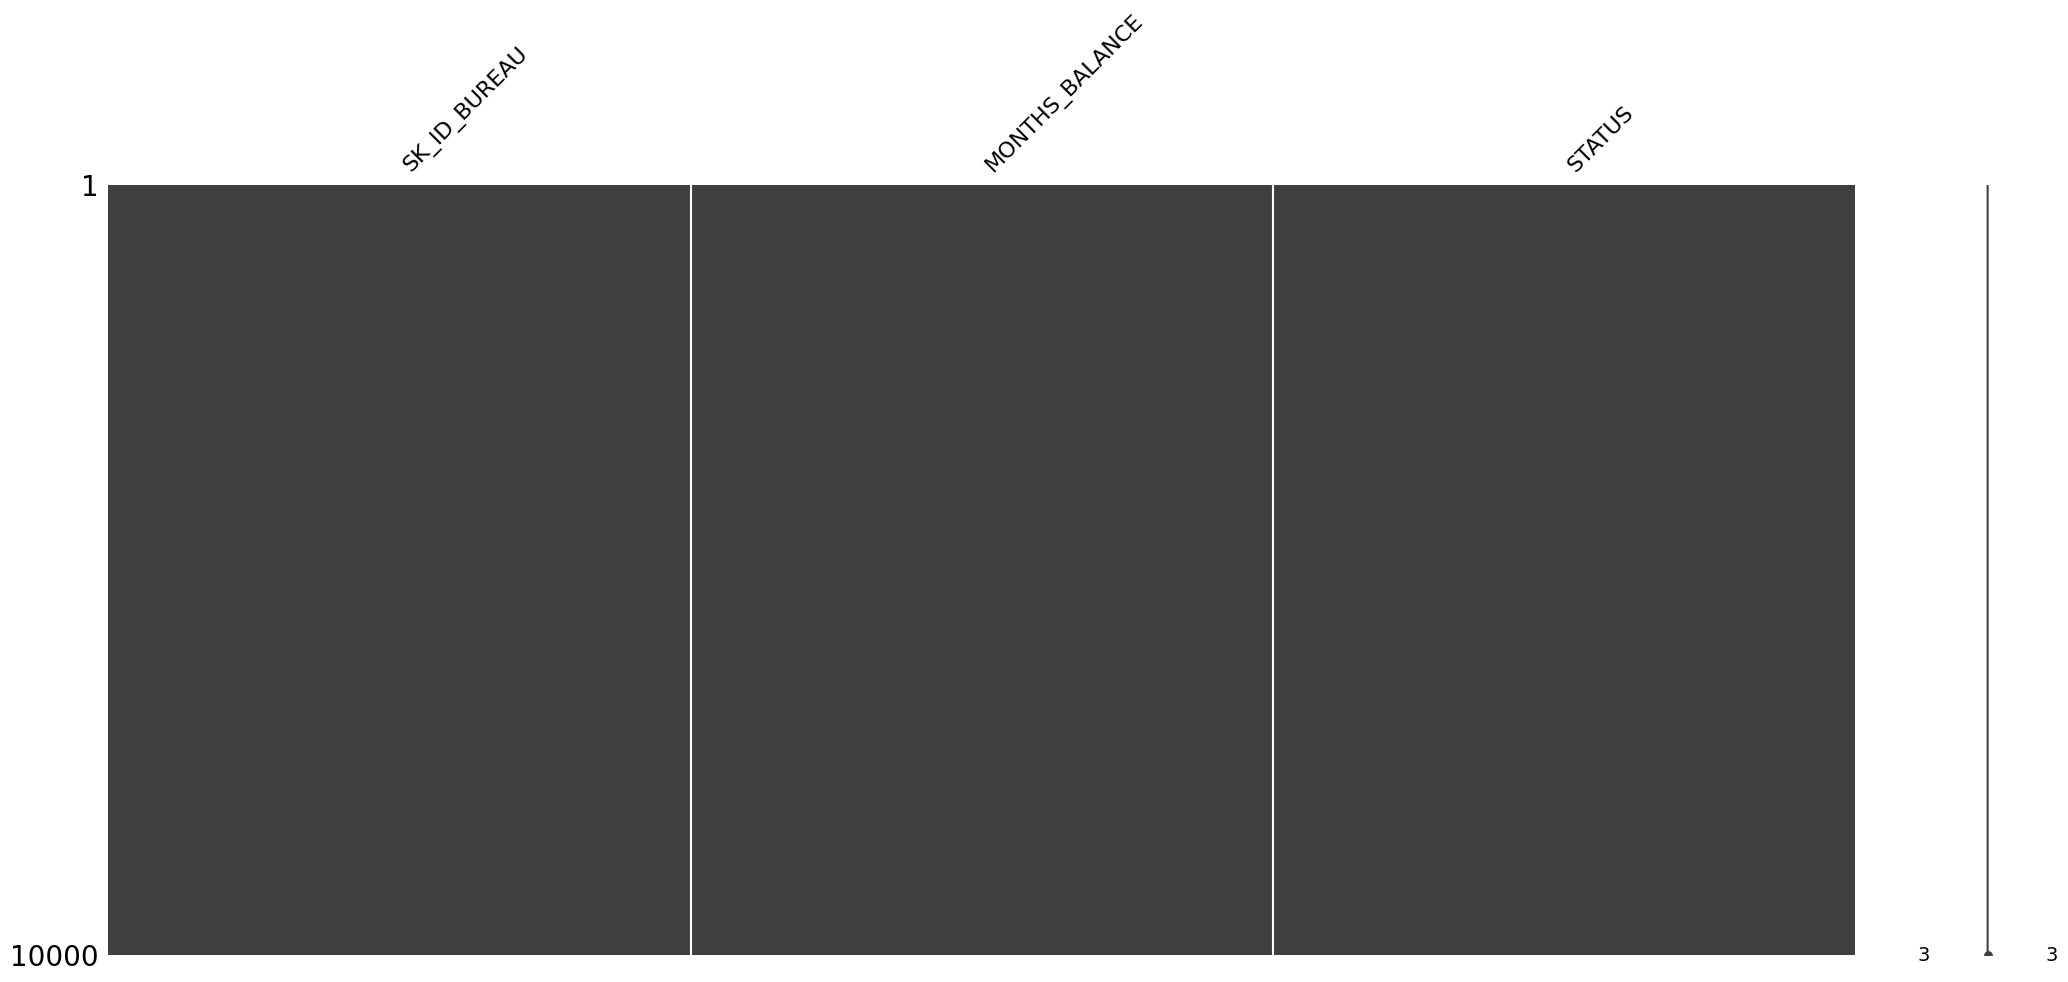

In [49]:
%matplotlib inline
msno.matrix(bureau_balance.sample(10000))

In [50]:
bureau_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [51]:
bureau_balance.describe()

,SK_ID_BUREAU,MONTHS_BALANCE
count,2.729992e+07,2.729992e+07
mean,6.036297e+06,-3.074169e+01
std,4.923489e+05,2.386451e+01
min,5.001709e+06,-9.600000e+01
25%,5.730933e+06,-4.600000e+01
50%,6.070821e+06,-2.500000e+01
75%,6.431951e+06,-1.100000e+01
max,6.842888e+06,0.000000e+00


In [52]:
bureau_balance[ 'MONTHS_BALANCE'].unique();

In [53]:
bureau_balance[ 'STATUS'].unique();

In [54]:
bureau_balance.isnull().mean() * 100

SK_ID_BUREAU      0.0
MONTHS_BALANCE    0.0
STATUS            0.0
dtype: float64

In [55]:
bureau_balance.duplicated();

In [56]:
bureau = pd.read_csv(r"C:\Users\chris\Initiez_vous_au_ML_Ops\data\bureau.csv")
print('Bureau data shape: ', bureau.shape)
bureau.head()

Bureau data shape:  (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


<Axes: >

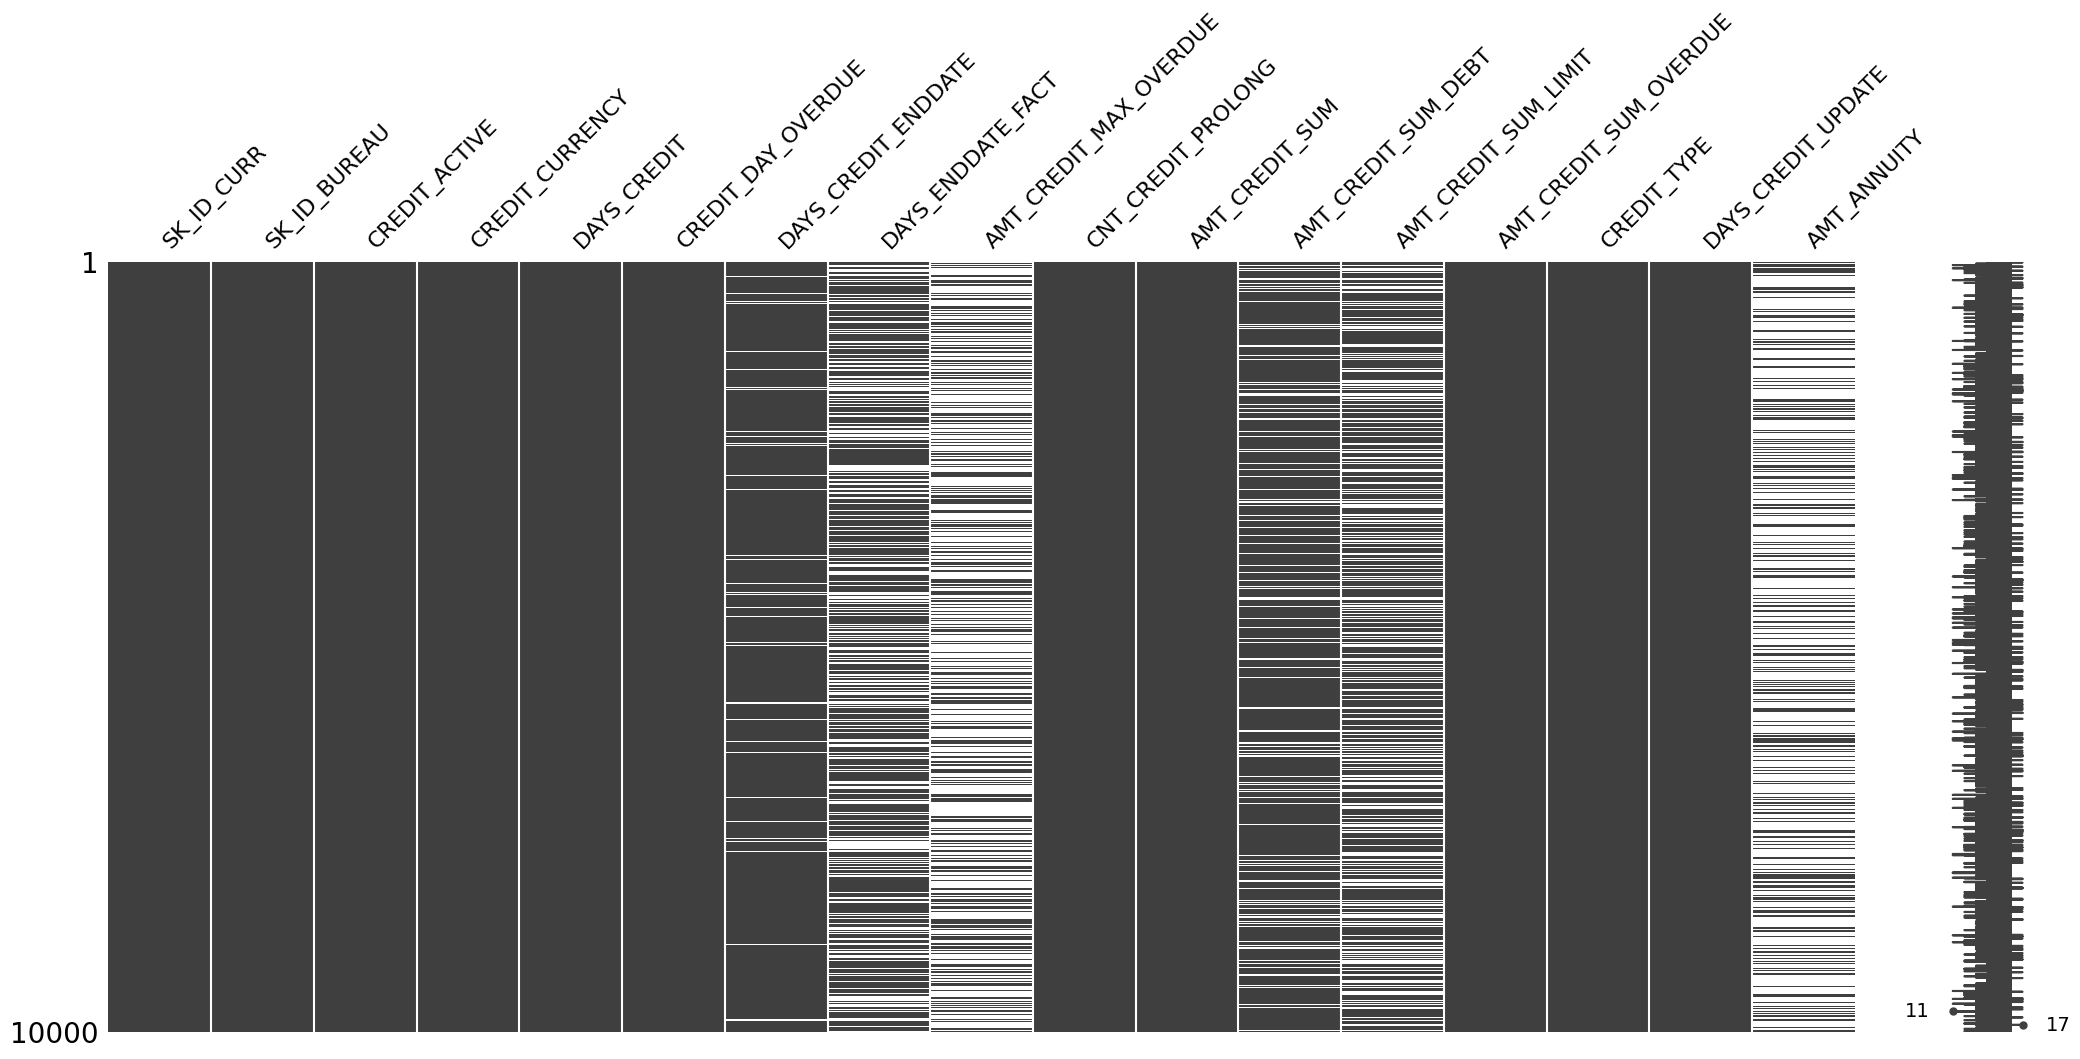

In [57]:
%matplotlib inline
msno.matrix(bureau.sample(10000))

In [58]:
bureau.isnull().mean() * 100;

In [59]:
bureau[ 'CREDIT_ACTIVE'].unique()

array(['Closed', 'Active', 'Sold', 'Bad debt'], dtype=object)

In [60]:
bureau[ 'CREDIT_CURRENCY'].unique()

array(['currency 1', 'currency 2', 'currency 4', 'currency 3'],
      dtype=object)

In [61]:
# âge du crédit
bureau[ 'DAYS_CREDIT'].unique()

array([-497, -208, -203, ...,    0,   -3,   -1], shape=(2923,))

In [62]:
bureau[ 'CREDIT_DAY_OVERDUE'].unique();

In [63]:
bureau[ 'DAYS_CREDIT_ENDDATE'].unique()

array([-153., 1075.,  528., ..., 5922., 3835., 5650.], shape=(14097,))

In [64]:
bureau[ 'DAYS_ENDDATE_FACT'].unique();

In [65]:
bureau[ 'AMT_CREDIT_MAX_OVERDUE'].unique();

In [66]:
bureau[ 'CNT_CREDIT_PROLONG'].unique();

In [67]:
bureau[ 'AMT_CREDIT_SUM'].unique()

array([ 91323.  , 225000.  , 464323.5 , ...,  77861.43, 112204.35,
       108765.72], shape=(236709,))

In [68]:
bureau[ 'AMT_CREDIT_SUM_DEBT'].unique()

array([      0.   ,  171342.   ,         nan, ...,  830860.875,
        146502.   , 1092226.5  ], shape=(226538,))

In [69]:
bureau[ 'AMT_CREDIT_SUM_LIMIT'].unique()

array([       nan, 108982.62 ,      0.   , ...,  10398.15 ,  10617.75 ,
       135035.865], shape=(51727,))

In [70]:
bureau[ 'AMT_CREDIT_SUM_LIMIT'].value_counts();

In [71]:
bureau[ 'AMT_CREDIT_SUM_OVERDUE'].unique();

In [72]:
bureau[ 'AMT_CREDIT_SUM_OVERDUE'].value_counts();

In [73]:
bureau[ 'CREDIT_TYPE'].unique();

In [74]:
bureau['DAYS_CREDIT_UPDATE'].unique()

array([  -131,    -20,    -16, ...,  -2901, -41918,  -2844], shape=(2982,))

In [75]:
bureau[ 'AMT_ANNUITY'].unique();

In [76]:
bureau.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1716423    False
1716424    False
1716425    False
1716426    False
1716427    False
Length: 1716428, dtype: bool

In [77]:
bureau.drop(columns=['CREDIT_CURRENCY','DAYS_ENDDATE_FACT','AMT_ANNUITY', 'AMT_CREDIT_MAX_OVERDUE', 'CREDIT_TYPE','AMT_CREDIT_SUM_LIMIT'
                     ,'AMT_CREDIT_SUM_OVERDUE']
            , inplace=True)

In [78]:
# One Hot Encoding
bureau_encoded = pd.get_dummies(bureau, drop_first=True)
bureau_balance_encoded = pd.get_dummies(bureau_balance, drop_first=True)


In [79]:
# Agrégation bureau_balance par SK_ID_BUREAU (par crédit)

bureau_balance_agg = bureau_balance_encoded.groupby("SK_ID_BUREAU").agg(["mean", "min", "max", "sum", "size"])
bureau_balance_agg.columns = ["bureau_balance_" + "_".join(col).upper() for col in bureau_balance_agg.columns]
bureau_balance_agg.reset_index(inplace=True)

print('Bureau_balance aggregated shape:', bureau_balance_agg.shape)

Bureau_balance aggregated shape: (817395, 41)


In [80]:
# Fusion bureau + bureau_balance_agg (niveau crédit)

bureau_fusion = bureau_encoded.merge(bureau_balance_agg, on="SK_ID_BUREAU", how="left")
print('Bureau merged with bureau_balance shape:', bureau_fusion.shape)

Bureau merged with bureau_balance shape: (1716428, 52)


In [81]:
# Traitement des NaN (avant agrégation client)

# SIZE et SUM : 0 = pas de statut enregistré
for col in bureau_fusion.columns:
    if 'bureau_balance' in col and ('_SIZE' in col or '_SUM' in col):
        bureau_fusion[col] = bureau_fusion[col].fillna(0)
    
    # MEAN/MIN/MAX : 0
    elif 'bureau_balance' in col and ('_MEAN' in col or '_MIN' in col or '_MAX' in col):
        bureau_fusion[col] = bureau_fusion[col].fillna(0)

In [82]:
# ÉTAPE 4 : Agrégation finale par SK_ID_CURR (par client)

bureau_agg = bureau_fusion.groupby("SK_ID_CURR").agg(["mean", "min", "max", "sum"])
bureau_agg.columns = ["bureau_" + "_".join(col).upper() for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

print('Final bureau_agg shape:', bureau_agg.shape)
bureau_agg.head()

Final bureau_agg shape: (305811, 205)


,SK_ID_CURR,bureau_SK_ID_BUREAU_MEAN,bureau_SK_ID_BUREAU_MIN,bureau_SK_ID_BUREAU_MAX,bureau_SK_ID_BUREAU_SUM,bureau_DAYS_CREDIT_MEAN,bureau_DAYS_CREDIT_MIN,bureau_DAYS_CREDIT_MAX,bureau_DAYS_CREDIT_SUM,bureau_CREDIT_DAY_OVERDUE_MEAN,...,bureau_BUREAU_BALANCE_STATUS_X_MAX_MAX,bureau_BUREAU_BALANCE_STATUS_X_MAX_SUM,bureau_BUREAU_BALANCE_STATUS_X_SUM_MEAN,bureau_BUREAU_BALANCE_STATUS_X_SUM_MIN,bureau_BUREAU_BALANCE_STATUS_X_SUM_MAX,bureau_BUREAU_BALANCE_STATUS_X_SUM_SUM,bureau_BUREAU_BALANCE_STATUS_X_SIZE_MEAN,bureau_BUREAU_BALANCE_STATUS_X_SIZE_MIN,bureau_BUREAU_BALANCE_STATUS_X_SIZE_MAX,bureau_BUREAU_BALANCE_STATUS_X_SIZE_SUM
0,100001,5896633.000,5896630,5896636,41276431,-735.000000,-1572,-49,-5145,0.0,...,True,5,4.285714,0.0,9.0,30.0,24.571429,2.0,52.0,172.0
1,100002,6153272.125,6113835,6158909,49226177,-874.000000,-1437,-103,-6992,0.0,...,True,6,1.875000,0.0,3.0,15.0,13.750000,4.0,22.0,110.0
2,100003,5885878.500,5885877,5885880,23543514,-1400.750000,-2586,-606,-5603,0.0,...,0,0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,100004,6829133.500,6829133,6829134,13658267,-867.000000,-1326,-408,-1734,0.0,...,0,0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,100005,6735201.000,6735200,6735202,20205603,-190.666667,-373,-62,-572,0.0,...,True,2,0.666667,0.0,1.0,2.0,7.000000,3.0,13.0,21.0
